scale: 10dBV/  
ref level: -50 dBV  
span: 1 kHz  
center: 400Hz  
window: hanning  
max points: 2M  
fft mode: normal  
search threshold: -160 dBV  
search excursion: 20 dB  
sort by: amplitude  
  
draadlengte (die beweegt): 31.5 +-0.1 cm  
metingen op: 8.9 +-0.1 cm  
1ste plek voor gewicht: 8 +-0.1 cm  
ruimte tussen plekken: 4 +-0.1 cm  
ruimte aan andere kant: 2 +- 0.1 cm  
gewicht: 1.0468 +-0.0001 kg  

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

In [14]:
#IMPORTING ALL FILES

#this script imports all data but keeps file structure intact by putting it in a dictionary
#print(results.keys()) shows all folders of different distances
#print(results["measurements x cm"].keys()) shows all positions used with distance x
#print(results["measurements x cm"]["y-z"].keys()) shows all measurements that were taken with distance x in position y-z
#here y is the position of the lighter weight and z is the position of the heavier one

#results["metingen 30 cm"]["metingen 4-4"]["fft (1)"] calling on the data like this, using the same names as the file structure
# (except for the csv file names, they have been changed to fft and raw to be more clear)

#use this to loop over all files:

# for cm_name, positions in results.items():
#     for position, measurements in positions.items():
#         for measurement_name, data in measurements.items():

#this prints the info of a file:
#print(f"{cm_name} / {position} / {measurement_name}: shape={data.shape}")

base_dir = Path("metingen")

position_names = [f"0-{i}" for i in range(1, 5)]+[f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

measurement_names = numbered_names("usr_wf_C1_data", 3) + numbered_names("usr_wf_F1_data", 3)

new_names = numbered_names("raw", 3) + numbered_names("fft", 3)

rename_map = dict(zip(measurement_names, new_names))

results = {}

for cm_folder in sorted(base_dir.iterdir()):
    if not cm_folder.is_dir():
        continue

    cm_folder_name = cm_folder.name
    print(f"Processing folder: {cm_folder_name}")
    results[cm_folder_name] = {}

    for position in position_names:
        position_folder = cm_folder / f"metingen {position}"
        position_key = position_folder.name

        if not position_folder.is_dir():
            print(f"  Missing folder: {position_folder}")
            continue

        results[cm_folder_name][position_key] = {}

        for measurement in measurement_names:
            file_path = position_folder / f"{measurement}.csv"

            if file_path.exists():
                data = np.loadtxt(file_path,skiprows = 12, delimiter = ",")
                key_name = rename_map.get(measurement, measurement)
                results[cm_folder_name][position_key][key_name] = data
            else:
                print(f"     Missing file: {file_path}")

Processing folder: metingen 23 cm
  Missing folder: metingen\metingen 23 cm\metingen 3-4
  Missing folder: metingen\metingen 23 cm\metingen 4-4
Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm


NameError: name 't' is not defined

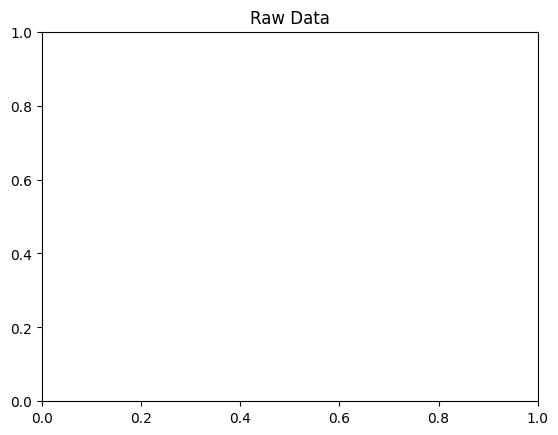

In [15]:
#raw data
plt.figure()
plt.title("Raw Data")

plt.plot(t, V, 'b-', linewidth = 0.05)

plt.xlabel("Time(s)")
plt.ylabel("Voltage(V)")

plt.show()

In [ ]:
#fft oscilloscope
plt.figure()
plt.title("Oscilloscope FFT")

plt.plot(f, A, 'r-', linewidth = 0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
#fft numpy
V_centered = V - np.mean(V)

N = len(V)
dt = np.mean(np.diff(t))
fs = 1/dt

window = np.hanning(N)
V_windowed = V_centered * window
fft_result = np.fft.rfft(V_windowed)

# Frequency bins corresponding to the FFT output
freqs = np.fft.rfftfreq(len(V), d=1/fs)

# Magnitude spectrum
magnitude = np.abs(fft_result)/N
magnitude[1:-1] *= 2
magnitude_db = 20*np.log10(magnitude/np.max(magnitude))

mask = freqs <= 250

#fft numpy

plt.figure()
plt.title("Numpy FFT")

plt.plot(freqs[mask], magnitude_db[mask], linewidth = 0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.show()